<a href="https://colab.research.google.com/github/Prerana-Bijekar/DL/blob/main/Practical-9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
max_features = 10000
maxlen = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000
Test samples: 25000


In [3]:
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (25000, 200)
Shape of X_test: (25000, 200)


In [4]:
rnn_model = Sequential([
    Embedding(input_dim=max_features, output_dim=128, input_length=maxlen),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = rnn_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 475ms/step - accuracy: 0.6289 - loss: 0.6296 - val_accuracy: 0.8394 - val_loss: 0.3677
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 472ms/step - accuracy: 0.8540 - loss: 0.3612 - val_accuracy: 0.8412 - val_loss: 0.3724
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 469ms/step - accuracy: 0.8568 - loss: 0.3427 - val_accuracy: 0.8320 - val_loss: 0.3899


In [6]:
# Predictions
y_pred = (rnn_model.predict(X_test) > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Test Accuracy: {acc:.3f}")

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step
✅ Test Accuracy: 0.834

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84     12500
           1       0.86      0.80      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



In [7]:
word_index = imdb.get_word_index()

def encode_review(text):
    import re
    text = re.sub(r"[^a-zA-Z']", " ", text).lower().split()
    encoded = [word_index.get(word, 2) for word in text]  # 2 = unknown
    padded = pad_sequences([encoded], maxlen=maxlen)
    return padded

def predict_sentiment(text):
    seq = encode_review(text)
    pred = rnn_model.predict(seq)[0][0]
    label = "Negative 😞" if pred > 0.5 else "Positive 😊"
    print(f"🎬 Review: {text}")
    print(f"Predicted Sentiment: {label} (Confidence: {pred:.3f})")

predict_sentiment(input("Review :"))
predict_sentiment(input("Review :"))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Review :The movie was absolutely amazing and thrilling!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
🎬 Review: The movie was absolutely amazing and thrilling!
Predicted Sentiment: Positive 😊 (Confidence: 0.455)
Review :It was boring and a total waste of time.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
🎬 Review: It was boring and a total waste of time.
Predicted Sentiment: Negative 😞 (Confidence: 0.906)


In [8]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [9]:
max_features = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

In [10]:
mlp_model = Sequential([
    Embedding(max_features, 128, input_length=max_len),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
mlp_model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
mlp_history = mlp_model.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.2)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step - accuracy: 0.6486 - loss: 0.5916 - val_accuracy: 0.8604 - val_loss: 0.3297
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 258ms/step - accuracy: 0.9638 - loss: 0.1147 - val_accuracy: 0.8322 - val_loss: 0.4299
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 274ms/step - accuracy: 0.9975 - loss: 0.0151 - val_accuracy: 0.8528 - val_loss: 0.4730


In [12]:
rnn_model = Sequential([
    Embedding(max_features, 128, input_length=max_len),
    SimpleRNN(128, dropout=0.5, recurrent_dropout=0.5),
    Dense(1, activation='sigmoid')
])

In [13]:
rnn_model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
rnn_history = rnn_model.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.2)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 340ms/step - accuracy: 0.5020 - loss: 0.7631 - val_accuracy: 0.4950 - val_loss: 0.7120
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 330ms/step - accuracy: 0.4949 - loss: 0.7221 - val_accuracy: 0.5108 - val_loss: 0.6952
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 330ms/step - accuracy: 0.5009 - loss: 0.7051 - val_accuracy: 0.4894 - val_loss: 0.6940


In [14]:
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype("int32")
mlp_pred = (mlp_model.predict(X_test) > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step


In [15]:
print("RNN Model Performance:")
print(classification_report(y_test, mlp_pred))

RNN Model Performance:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     12500
           1       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [16]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(10,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


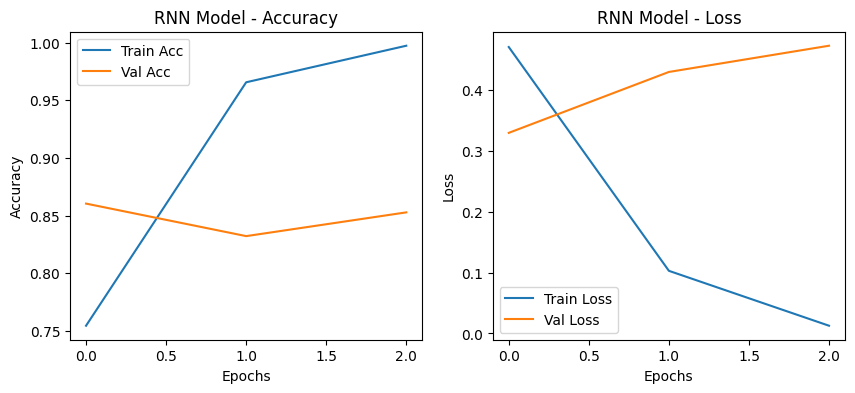

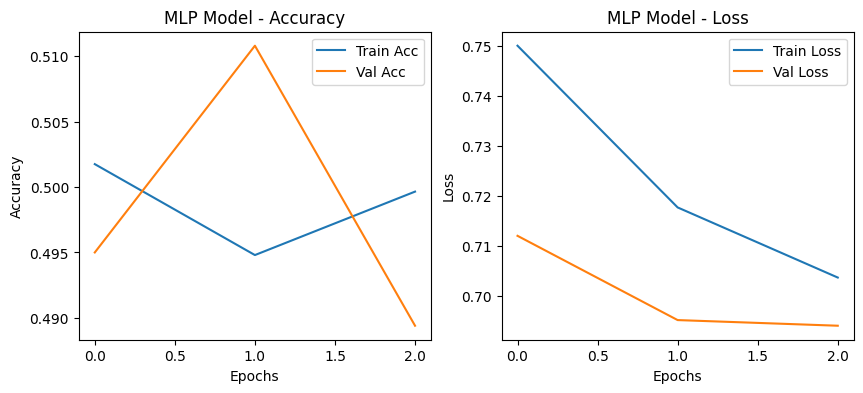

In [17]:
plot_history(mlp_history, 'RNN Model')
plot_history(rnn_history, 'MLP Model')

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step


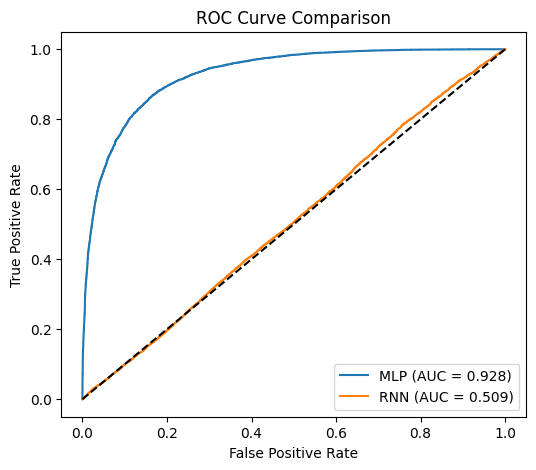

In [18]:
from sklearn.metrics import roc_curve, auc

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_model.predict(X_test))
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, rnn_model.predict(X_test))

plt.figure(figsize=(6,5))
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot(fpr_rnn, tpr_rnn, label=f'RNN (AUC = {auc(fpr_rnn, tpr_rnn):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [19]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


word_index = imdb.get_word_index()

max_features = 10000
max_len = 200


In [20]:
def encode_review(text):
    words = text.lower().split()
    encoded = [word_index.get(w, 2) for w in words]  # 2 = <UNK> for unknown words
    padded = pad_sequences([encoded], maxlen=max_len)
    return padded

In [21]:
def predict_sentiment(review):
    seq = encode_review(review)
    prediction = rnn_model.predict(seq)[0][0]

    if prediction > 0.5:
        print(f"🎬 Sentiment: Positive 😊 (Confidence: {prediction:.3f})")
    else:
        print(f"🎬 Sentiment: Negative 😞 (Confidence: {prediction:.3f})")


In [22]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Load IMDB index
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

max_features = 10000
max_len = 200

# Improved encoder
def encode_review_fixed(text):
    # remove punctuation and lowercase
    import re
    text = re.sub(r"[^a-zA-Z']", " ", text).lower().split()
    encoded = [word_index.get(word, 2) for word in text]  # 2 = unknown
    padded = pad_sequences([encoded], maxlen=max_len)
    return padded